In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("../data/cardio_train.csv", sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [10]:
df.shape

(70000, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [12]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
# Convert age to years
df['age'] = df['age'] / 365

# Drop id column
df.drop('id', axis=1, inplace=True)

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0


In [14]:
# Remove unrealistic blood pressure
df = df[(df['ap_hi'] > 50) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 30) & (df['ap_lo'] < 200)]

# Ensure systolic > diastolic
df = df[df['ap_hi'] > df['ap_lo']]

In [15]:
df.shape

(68672, 12)

In [16]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)

In [17]:
df['age_group'] = pd.cut(df['age'],
                         bins=[0,30,45,60,100],
                         labels=[0,1,2,3])

In [18]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000,68672.000000
mean,53.327765,1.348628,164.360860,74.118119,126.674132,81.307374,1.364661,1.225725,0.087969,0.053355,0.803355,0.494714,27.521565
std,6.762144,0.476540,8.183657,14.331489,16.694859,9.454808,0.678893,0.571592,0.283252,0.224742,0.397464,0.499976,6.051653
min,29.583562,1.000000,55.000000,11.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.471784
25%,48.378082,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.975342,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.422603,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.119376
max,64.967123,2.000000,250.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,298.666667


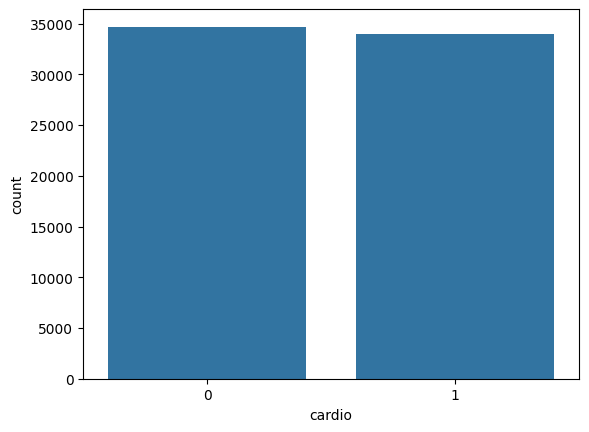

In [19]:
sns.countplot(x='cardio', data=df)
plt.show()

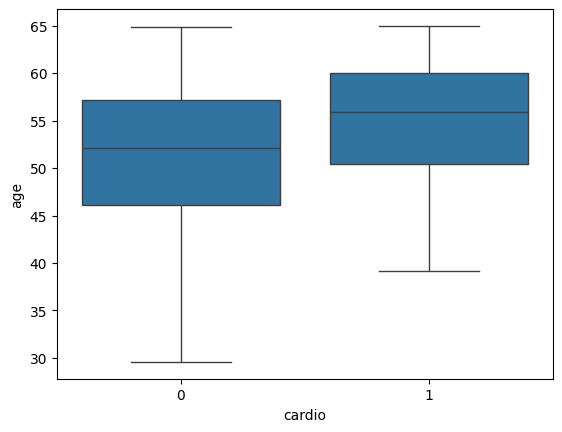

In [20]:
sns.boxplot(x='cardio', y='age', data=df)
plt.show()

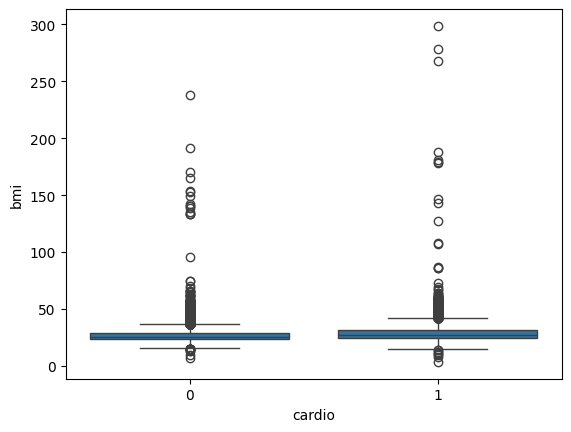

In [21]:
sns.boxplot(x='cardio', y='bmi', data=df)
plt.show()

In [22]:
df.to_csv("../data/cleaned_cardio.csv", index=False)

In [23]:
# Remove unrealistic height
df = df[(df['height'] > 120) & (df['height'] < 220)]

# Remove unrealistic weight
df = df[(df['weight'] > 30) & (df['weight'] < 200)]

# Remove unrealistic BMI
df = df[(df['bmi'] > 10) & (df['bmi'] < 60)]

In [24]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000
mean,53.328461,1.348649,164.437521,74.085881,126.674806,81.308245,1.364810,1.225835,0.087997,0.053370,0.803396,0.494727,27.432160
std,6.761244,0.476546,7.848988,14.204520,16.691800,9.454043,0.679007,0.571685,0.283293,0.224772,0.397434,0.499976,5.167169
min,29.583562,1.000000,125.000000,31.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.378082,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.975342,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.421918,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.116213
max,64.967123,2.000000,207.000000,183.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,59.523810


In [25]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000,68559.000000
mean,53.328461,1.348649,164.437521,74.085881,126.674806,81.308245,1.364810,1.225835,0.087997,0.053370,0.803396,0.494727,27.432160
std,6.761244,0.476546,7.848988,14.204520,16.691800,9.454043,0.679007,0.571685,0.283293,0.224772,0.397434,0.499976,5.167169
min,29.583562,1.000000,125.000000,31.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.378082,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,53.975342,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.421918,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.116213
max,64.967123,2.000000,207.000000,183.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,59.523810


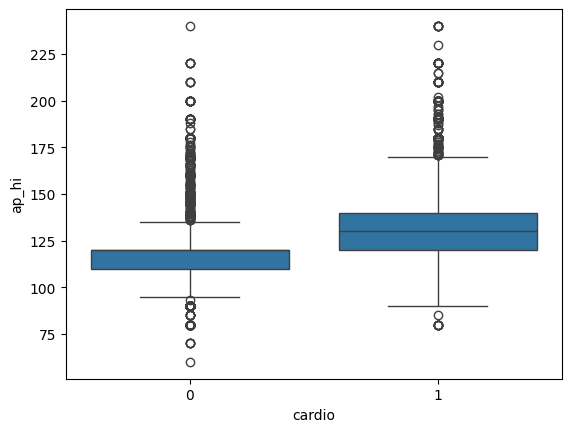

In [26]:
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.show()

In [28]:
df.to_csv("../data/final_cardio.csv", index=False)

In [29]:
df = pd.read_csv("../data/final_cardio.csv")
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_group
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,2
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,2
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,2
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,2
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,2


In [30]:
import pandas as pd

df = pd.read_csv("../data/final_cardio.csv")
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_group
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,2
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,2
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,2
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,2
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,2


In [31]:
X = df.drop('cardio', axis=1)
y = df['cardio']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
X = pd.get_dummies(X, columns=['age_group'], drop_first=True)

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6960
           1       0.74      0.67      0.70      6752

    accuracy                           0.72     13712
   macro avg       0.72      0.72      0.72     13712
weighted avg       0.72      0.72      0.72     13712

ROC-AUC: 0.7872839401352345


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.71      0.72      0.72      6960
           1       0.71      0.70      0.70      6752

    accuracy                           0.71     13712
   macro avg       0.71      0.71      0.71     13712
weighted avg       0.71      0.71      0.71     13712

ROC-AUC: 0.7692749615269379


In [38]:
X = df.drop('cardio', axis=1)

# Apply encoding AGAIN
X = pd.get_dummies(X, columns=['age_group'], drop_first=True)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
import pandas as pd

importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp.sort_values(ascending=False)

age            0.236216
ap_hi          0.175724
bmi            0.158519
weight         0.120345
height         0.111930
ap_lo          0.075789
cholesterol    0.037721
gluc           0.016960
gender         0.014735
active         0.013600
age_group_1    0.009941
age_group_3    0.008572
smoke          0.008172
alco           0.006582
age_group_2    0.005194
dtype: float64

In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

y_prob_xgb = xgb.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

c:\Users\Priyanka Sati\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:40:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6960
           1       0.74      0.69      0.71      6752

    accuracy                           0.73     13712
   macro avg       0.73      0.73      0.73     13712
weighted avg       0.73      0.73      0.73     13712

ROC-AUC: 0.7912700728094187


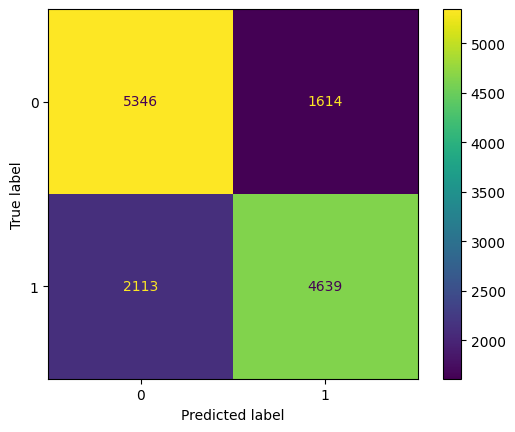

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

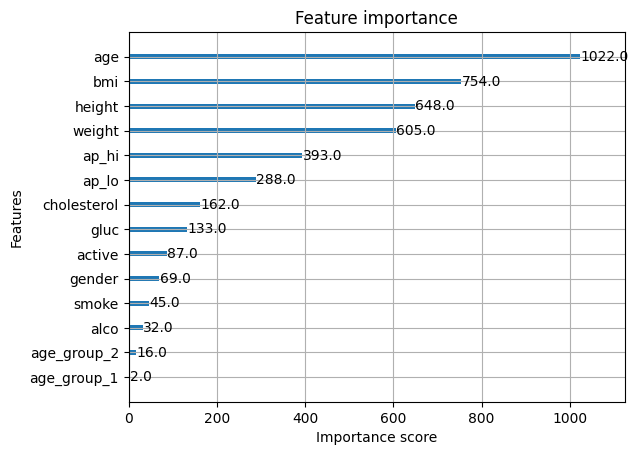

In [45]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb)
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv("../data/final_cardio.csv")
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_group
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,2
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,2
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,2
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,2
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,2


In [4]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


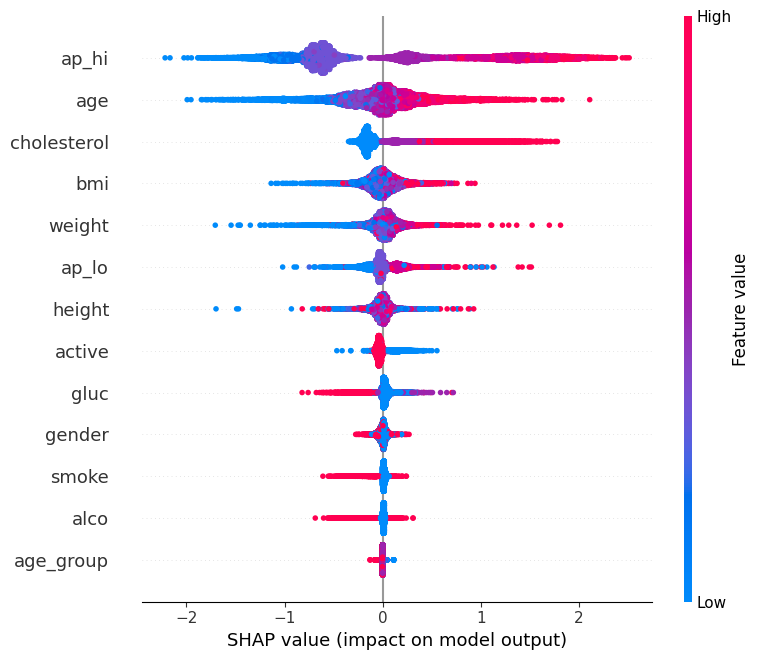

In [7]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)